# Analyse Kiprix — Groupe 2
Notebook d'exploration des données scrapées depuis kiprix.com.

In [1]:
from pathlib import Path
import pandas as pd
import re

data_path = Path('../data/raw/kiprix_mq.json')
if not data_path.exists():
    # Essayer la Guadeloupe si Martinique n'existe pas
    data_path = Path('../data/raw/kiprix_gp.json')
    
if data_path.exists():
    df = pd.read_json(data_path)
    print(f'Produits chargés depuis {data_path.name} : {len(df)}')
    display(df.head())
else:
    print("Aucun fichier de données trouvé. Lancez d'abord le scraping.")
    df = pd.DataFrame()

Produits chargés depuis kiprix_mq.json : 40


,name,url,price_france,price_dom,difference,quantity_value,quantity_unit,unit_reference,unit_price_france,unit_price_dom,territory,territory_name
0,Bière blonde Pélican 6x33cl,https://www.kiprix.com/fr-mq/produit/16701,"7,95 €","15,95 €","+ 100,63%",33.00,cl,€/L,24.09,48.33,mq,Martinique
1,Thé glacé Lipton Ice Tea Pêche - 6x33cl,https://www.kiprix.com/fr-mq/produit/16604,"2,97 €","5,99 €","+ 101,68%",33.00,cl,€/L,9.00,18.15,mq,Martinique
2,Thé glacé Lipton Ice Tea Framboise - 1.25L,https://www.kiprix.com/fr-mq/produit/20084,"1,55 €","2,65 €","+ 70,97%",1.25,l,€/L,1.24,2.12,mq,Martinique
3,Bière blanche Grimbergen 6x25cl,https://www.kiprix.com/fr-mq/produit/5147,"5,95 €","9,29 €","+ 56,13%",25.00,cl,€/L,23.80,37.16,mq,Martinique
4,Tablettes lave-vaisselle Uni Vert - Classiques...,https://www.kiprix.com/fr-mq/produit/83211,"6,27 €","3,55 €",,450.00,g,€/kg,13.93,7.89,mq,Martinique


### 1. Nettoyage des données
Transformation des prix et des pourcentages en valeurs numériques.

In [2]:
if not df.empty:
    def parse_diff(value):
        match = re.search(r'([+-]?\s*\d+[\d\s.,]*)\s*%', str(value))
        if not match:
            return None
        cleaned = match.group(1).replace(' ', '').replace('\u00a0', '').replace(',', '.')
        try:
            return float(cleaned)
        except ValueError:
            return None

    df['difference_numeric'] = df['difference'].apply(parse_diff)
    df['price_france_num'] = pd.to_numeric(
        df['price_france'].astype(str).str.replace('€', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )
    df['price_dom_num'] = pd.to_numeric(
        df['price_dom'].astype(str).str.replace('€', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )

    display(df[['difference_numeric', 'price_france_num', 'price_dom_num']].describe())

,difference_numeric,price_france_num,price_dom_num
count,38.000000,40.000000,40.000000
mean,55.130000,4.319500,6.598000
std,28.961923,3.499265,5.431663
min,9.060000,0.600000,1.090000
25%,27.745000,2.310000,3.160000
50%,54.775000,3.375000,4.920000
75%,80.895000,5.552500,8.127500
max,113.700000,16.650000,24.000000


### 2. Statistiques globales

In [3]:
if not df.empty:
    summary = {
        'total_produits': int(len(df)),
    }
    if 'difference_numeric' in df.columns and df['difference_numeric'].notna().any():
        summary.update({
            'moyenne_ecart_pct': float(df['difference_numeric'].dropna().mean()),
            'mediane_ecart_pct': float(df['difference_numeric'].dropna().median()),
            'max_ecart_pct': float(df['difference_numeric'].dropna().max()),
            'min_ecart_pct': float(df['difference_numeric'].dropna().min()),
        })
    display(summary)

{'total_produits': 40,
 'moyenne_ecart_pct': 55.12999999999999,
 'mediane_ecart_pct': 54.775,
 'max_ecart_pct': 113.7,
 'min_ecart_pct': 9.06}

### 3. Top 5 des produits les plus chers en DOM

In [4]:
if not df.empty and 'price_dom_num' in df.columns:
    top5_dom = df.dropna(subset=['price_dom_num']).nlargest(5, 'price_dom_num')[['name', 'territory_name', 'price_dom', 'difference']]
    display(top5_dom)

,name,territory_name,price_dom,difference
33,Couches Pampers Baby-Dry Night Pants - T5 -x35,Martinique,"24,00 €","+ 47,97%"
34,Couches Pampers Harmonie Taille 5 - x31,Martinique,"22,90 €","+ 37,54%"
0,Bière blonde Pélican 6x33cl,Martinique,"15,95 €","+ 100,63%"
8,AOP Château Caillau Saint- Emilion Grand cru -...,Martinique,"13,95 €","+ 40,20%"
31,Après-shampooing DermaXPro Hydrate - 200ml,Martinique,"12,95 €","+ 113,70%"


### 4. Visualisations

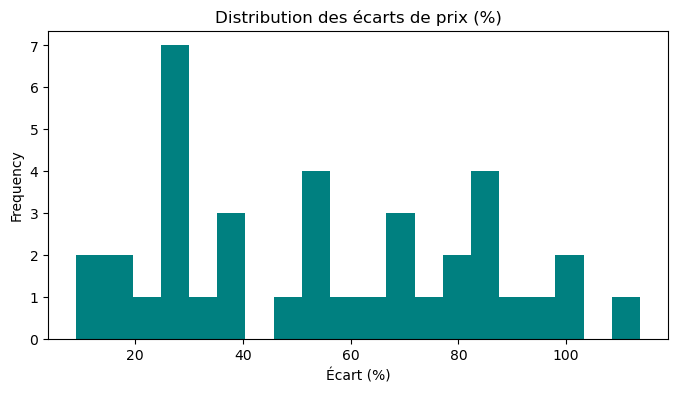

In [5]:
if not df.empty and 'difference_numeric' in df.columns:
    try:
        import matplotlib.pyplot as plt

        ax = df['difference_numeric'].dropna().plot(kind='hist', bins=20, title='Distribution des écarts de prix (%)', figsize=(8, 4), color='teal')
        ax.set_xlabel('Écart (%)')
        plt.show()
    except ModuleNotFoundError:
        print('matplotlib non installé. Installe-le avec: pip install matplotlib')